# Feature Engineering Testing

Evaluasi final pada 10.000 official test. Tiga embedding dan empat descriptor dihitung dari model/rumus final; tidak ada training atau pemilihan parameter. Accuracy ≥95% hanya dinyatakan bila benar-benar tercapai.

## 1. Konfigurasi
Baca artefak dari run yang sama.

In [1]:
from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import tensorflow as tf

RUN_ID = "cifar10_7fitur_v1"
SEED = 30092026
ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / RUN_ID / "fusion"

for folder in ("model", "fitur", "laporan"):
    (OUT / folder).mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

I0000 00:00:1791493880.938743  213863 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791493880.975770  213863 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791493881.898473  213863 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Rumus konversi citra
AVG dan NTSC sama dengan notebook varian.

In [2]:
def prepare_images(x, variant):
    x = np.asarray(x, dtype=np.float32) / 255.0

    if variant == "rgb":
        return x
    if variant == "avg":
        return np.mean(x, axis=-1, keepdims=True, dtype=np.float32)
    if variant == "ntsc":
        weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
        return np.sum(x * weights, axis=-1, keepdims=True)

    raise ValueError(f"Varian tidak dikenal: {variant}")

## 3. Descriptor tujuh fitur
Fungsi ini sama dengan Combination; tidak memiliki tahap fitting.

In [3]:
def handcrafted_descriptors(x, batch_size=128, verbose=1):
    # HOG: 9 orientasi unsigned, cell 8x8, block 2x2, L2 per block.
    # LBP: 8 tetangga radius 1, histogram 256 kode.
    # HSV: 16 bin per kanal. Statistik RGB: mean, std, skewness per kanal.
    import matplotlib.colors as mcolors
    outputs = {k: [] for k in ("hog", "lbp", "hsv", "rgb_stats")}
    total_batches = int(np.ceil(len(x) / batch_size))
    progress_interval = max(1, total_batches // 20)
    for begin in range(0, len(x), batch_size):
        rgb = np.asarray(x[begin:begin+batch_size], dtype=np.float32) / 255.0
        gray = np.sum(rgb * np.array([0.299, 0.587, 0.114], np.float32), axis=-1)
        gy, gx = np.gradient(gray, axis=(1, 2))
        magnitude = np.sqrt(gx*gx + gy*gy)
        orientation = np.mod(np.arctan2(gy, gx) * (180.0 / np.pi), 180.0)
        bins = np.minimum((orientation / 20.0).astype(np.int32), 8)
        cell_hist = np.zeros((len(rgb), 4, 4, 9), dtype=np.float32)
        for row in range(4):
            for col in range(4):
                b = bins[:, row*8:(row+1)*8, col*8:(col+1)*8]
                m = magnitude[:, row*8:(row+1)*8, col*8:(col+1)*8]
                for angle in range(9):
                    cell_hist[:, row, col, angle] = np.sum(m * (b == angle), axis=(1, 2))
        blocks = []
        for row in range(3):
            for col in range(3):
                block = cell_hist[:, row:row+2, col:col+2, :].reshape(len(rgb), -1)
                denominator = np.maximum(
                    np.linalg.norm(block, axis=1, keepdims=True), 1e-8
                )
                blocks.append(block / denominator)
        outputs["hog"].append(np.concatenate(blocks, axis=1))
        padded = np.pad(gray, ((0, 0), (1, 1), (1, 1)), mode="edge")
        lbp = np.zeros(gray.shape, dtype=np.uint8)
        offsets = [(-1,-1), (-1,0), (-1,1), (0,1), (1,1), (1,0), (1,-1), (0,-1)]
        for bit, (dy, dx) in enumerate(offsets):
            neighbor = padded[:, 1+dy:33+dy, 1+dx:33+dx]
            lbp |= (neighbor >= gray).astype(np.uint8) << bit
        hist = np.zeros((len(rgb), 256), dtype=np.float32)
        np.add.at(hist, (np.repeat(np.arange(len(rgb)), 1024), lbp.reshape(-1)), 1)
        outputs["lbp"].append(hist / 1024.0)
        hsv = mcolors.rgb_to_hsv(rgb)
        hsv_hist = np.zeros((len(rgb), 3, 16), dtype=np.float32)
        for channel in range(3):
            hsv_bin = np.minimum((hsv[..., channel] * 16).astype(np.int32), 15)
            np.add.at(hsv_hist[:, channel, :],
                      (np.repeat(np.arange(len(rgb)), 1024), hsv_bin.reshape(-1)), 1)
        outputs["hsv"].append(hsv_hist.reshape(len(rgb), -1) / 1024.0)
        flat = rgb.reshape(len(rgb), -1, 3)
        mean = flat.mean(axis=1)
        std = flat.std(axis=1)
        skew = np.mean(((flat - mean[:, None, :]) / np.maximum(std[:, None, :], 1e-6)) ** 3, axis=1)
        outputs["rgb_stats"].append(np.concatenate((mean, std, skew), axis=1))
        batch_number = begin // batch_size + 1
        if verbose == 1 and (
            batch_number % progress_interval == 0
            or batch_number == total_batches
        ):
            processed = min(begin + batch_size, len(x))
            print(f"Descriptor: {processed}/{len(x)} gambar", flush=True)
    result = {key: np.concatenate(parts).astype(np.float32) for key, parts in outputs.items()}
    assert [result[k].shape[1] for k in ("hog", "lbp", "hsv", "rgb_stats")] == [324, 256, 48, 9]
    assert all(np.isfinite(value).all() for value in result.values())
    return result

## 4. Definisi pembobot
Kelas diperlukan untuk memuat pipeline SVM tersimpan.

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin
class BlockWeight(TransformerMixin, BaseEstimator):
    def __init__(self, extra_weight=1.0, embedding_dim=1536):
        self.extra_weight, self.embedding_dim = extra_weight, embedding_dim
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        result = np.asarray(X, dtype=np.float32).copy()
        result[:, self.embedding_dim:] *= self.extra_weight
        return result

## 5. Muat SVM final
Periksa jenis model, jumlah kelompok, batas blok, dan versi preprocessing.

In [5]:
fusion_payload = joblib.load(OUT / "model" / "fusion_svm.joblib")
baseline_payload = joblib.load(OUT / "model" / "baseline_svm.joblib")
assert fusion_payload["run_id"] == RUN_ID and baseline_payload["run_id"] == RUN_ID
assert fusion_payload["feature_groups"] == 7 and baseline_payload["feature_groups"] == 3
assert fusion_payload["preprocessing_version"] == "v1"
assert fusion_payload["boundaries"] == [0, 512, 1024, 1536, 1860, 2116, 2164, 2173]
assert baseline_payload["model_hashes"] == fusion_payload["model_hashes"]
fusion_svm = fusion_payload["pipeline"]
baseline_svm = baseline_payload["pipeline"]

## 6. Muat tiga CNN
Cocokkan hash model dengan metadata Training gabungan sebelum ekstraksi.

In [6]:
extractors = {}
for variant, expected_hash in zip(("rgb", "avg", "ntsc"), fusion_payload["model_hashes"]):
    model_path = ROOT / "outputs" / RUN_ID / variant / "model" / "cnn.keras"
    assert hashlib.sha256(model_path.read_bytes()).hexdigest() == expected_hash
    cnn = tf.keras.models.load_model(model_path, compile=False)
    extractors[variant] = tf.keras.Model(cnn.input, cnn.get_layer("embedding").output)
print("Tiga hash CNN cocok")

I0000 00:00:1791493883.253354  213863 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4139 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Tiga hash CNN cocok


## 7. Muat official test
Dataset test hanya digunakan mulai tahap inferensi ini.

In [7]:
from tensorflow.keras.datasets import cifar10
(_, _), (x_test, y_test) = cifar10.load_data()
y_test = y_test.ravel().astype(np.int64)
assert x_test.shape == (10000, 32, 32, 3)

## 8. Tiga embedding test
Setiap CNN memproses gambar sesuai kanalnya tanpa augmentasi training.

In [8]:
cnn_test = {}
for variant in ("rgb", "avg", "ntsc"):
    cnn_test[variant] = extractors[variant].predict(prepare_images(x_test, variant),
                                                     batch_size=128, verbose=1).astype(np.float32)
    assert cnn_test[variant].shape == (10000, 512)

I0000 00:00:1791493886.586111  213932 cuda_dnn.cc:461] Loaded cuDNN version 92600


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step


## 9. Empat descriptor test
Gunakan perhitungan deterministik identik dengan Combination.

In [9]:
handcrafted_test = handcrafted_descriptors(x_test, batch_size=128, verbose=1)
print({k: v.shape for k, v in handcrafted_test.items()})

Descriptor: 384/10000 gambar
Descriptor: 768/10000 gambar
Descriptor: 1152/10000 gambar
Descriptor: 1536/10000 gambar
Descriptor: 1920/10000 gambar
Descriptor: 2304/10000 gambar
Descriptor: 2688/10000 gambar
Descriptor: 3072/10000 gambar
Descriptor: 3456/10000 gambar
Descriptor: 3840/10000 gambar
Descriptor: 4224/10000 gambar
Descriptor: 4608/10000 gambar
Descriptor: 4992/10000 gambar
Descriptor: 5376/10000 gambar
Descriptor: 5760/10000 gambar
Descriptor: 6144/10000 gambar
Descriptor: 6528/10000 gambar
Descriptor: 6912/10000 gambar
Descriptor: 7296/10000 gambar
Descriptor: 7680/10000 gambar
Descriptor: 8064/10000 gambar
Descriptor: 8448/10000 gambar
Descriptor: 8832/10000 gambar
Descriptor: 9216/10000 gambar
Descriptor: 9600/10000 gambar
Descriptor: 9984/10000 gambar
Descriptor: 10000/10000 gambar
{'hog': (10000, 324), 'lbp': (10000, 256), 'hsv': (10000, 48), 'rgb_stats': (10000, 9)}


## 10. Susun tujuh blok test
Periksa urutan dan dimensi sebelum prediksi.

In [10]:
combined_test = np.concatenate([cnn_test[k] for k in ("rgb", "avg", "ntsc")] +
                               [handcrafted_test[k] for k in (
                                   "hog", "lbp", "hsv", "rgb_stats"
                               )], axis=1)
assert combined_test.shape == (10000, 2173) and np.isfinite(combined_test).all()
np.savez_compressed(OUT / "fitur" / "test_combined.npz", features=combined_test,
                    y=y_test, indices=np.arange(10000), run_id=RUN_ID,
                    model_hashes=np.array(fusion_payload["model_hashes"]))

## 11. Prediksi pembanding
Model tiga embedding dipakai untuk mengukur kontribusi empat descriptor tambahan.

In [11]:
baseline_pred = baseline_svm.predict(combined_test[:, :1536])
assert baseline_pred.shape == y_test.shape

## 12. Prediksi tujuh fitur
Model akhir menggunakan seluruh tujuh kelompok fitur.

In [12]:
pred = fusion_svm.predict(combined_test)
assert pred.shape == y_test.shape

## 13. Metrik final
Simpan accuracy, macro-F1, classification report, confusion matrix, dan prediksi per sampel. Status target memakai hasil official test yang nyata.

In [13]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import matplotlib.pyplot as plt
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
baseline_accuracy = float(accuracy_score(y_test, baseline_pred))
metrics = {"run_id": RUN_ID, "variant": "fusion", "accuracy": float(accuracy_score(y_test, pred)),
           "macro_f1": float(f1_score(y_test, pred, average="macro")),
           "classification_report": classification_report(
               y_test, pred, target_names=CLASS_NAMES, output_dict=True
           ),
           "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
           "baseline_accuracy": baseline_accuracy,
           "target_accuracy": 0.95}
metrics["accuracy_delta"] = metrics["accuracy"] - baseline_accuracy
metrics["target_status"] = "tercapai" if metrics["accuracy"] >= 0.95 else "belum tercapai"
(OUT / "laporan" / "test_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
np.savez_compressed(OUT / "laporan" / "test_predictions.npz", indices=np.arange(10000),
                    y_true=y_test, y_pred=pred, baseline_pred=baseline_pred)
print(classification_report(y_test, pred, target_names=CLASS_NAMES))
print("Pembanding:", baseline_accuracy, "Gabungan:", metrics["accuracy"],
      "Selisih:", metrics["accuracy_delta"], "Target:", metrics["target_status"])

              precision    recall  f1-score   support

    airplane       0.94      0.94      0.94      1000
  automobile       0.96      0.97      0.97      1000
        bird       0.91      0.90      0.90      1000
         cat       0.86      0.86      0.86      1000
        deer       0.91      0.93      0.92      1000
         dog       0.90      0.89      0.89      1000
        frog       0.96      0.96      0.96      1000
       horse       0.95      0.95      0.95      1000
        ship       0.96      0.96      0.96      1000
       truck       0.97      0.95      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

Pembanding: 0.9293 Gabungan: 0.9314 Selisih: 0.0020999999999999908 Target: belum tercapai


## 14. Grafik confusion matrix
Simpan visualisasi final sepuluh kelas.

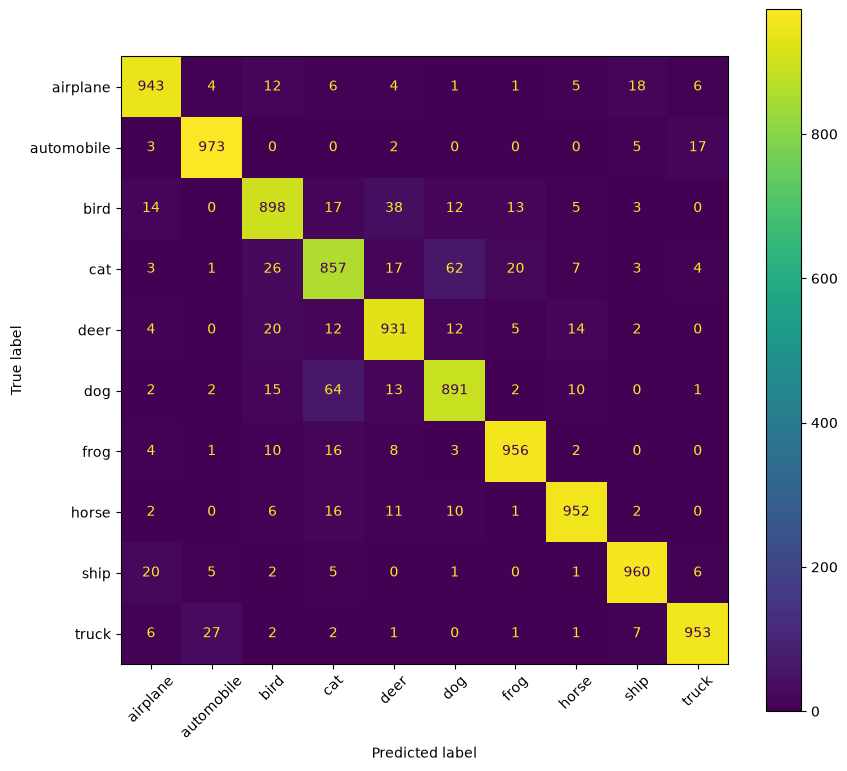

In [14]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=CLASS_NAMES, xticks_rotation=45
)
disp.figure_.set_size_inches(9, 8)
disp.figure_.tight_layout()
disp.figure_.savefig(OUT / "laporan" / "confusion_matrix.png", dpi=150)
plt.show()